# Tutorial 9 · Nowcasting with links, radar and weather stations together

Tutorial 7 nowcast one field at a time; tutorial 5 and 6 built rain maps from links (CMLs)
and personal weather stations (PWS) and merged them into the radar. This tutorial puts the
three together for **nowcasting**: how to bring every sensor onto one grid every five
minutes, which field to move and along whose motion, and what a neural network does with all
of them at once. Each step is written out by hand first, then done with the code of
[`projects/nowcasting/multisensor`](../projects/nowcasting/multisensor/README.md), which runs the
same study over a whole summer in Gothenburg and over the rain events of a winter in New York.

| | |
|---|---|
| **Data** | OpenMRG example subset, Gothenburg, 22-29 July 2015: 364 links, SMHI radar every 5 min, 10 city gauges (Andersson et al. 2022); the OpenMRG2 Netatmo PWS for the same days when present on disk |
| **You will learn** | one 5-minute grid for every sensor; link and PWS maps with missing data; radar adjusted with links and PWS; nowcasting a sensor map along its own motion or the radar's; scoring every nowcast on the same cells and gauges; a U-Net with and without the sensors |
| **Runtime** | about 8 minutes on a laptop CPU, most of it training two small networks |
| **Prerequisites** | tutorials 5 (maps), 6 (adjustment) and 7 (pysteps) |

**Contents**
1. The data, on one grid every 5 minutes
2. Link and PWS maps, by hand
3. Radar adjusted with links and PWS, by hand
4. Whose motion? Nowcasting a sensor map
5. Scoring every nowcast the same way
6. Learning from all three sensors
7. At scale: the project's results
8. Summary
9. References and links

In [1]:
import os

# torch and pysteps both bring an OpenMP runtime; on macOS they crash when they share a
# process unless OpenMP uses one thread. This must be set before either is imported.
os.environ.setdefault("OMP_NUM_THREADS", "1")

import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects" / "nowcasting" / "multisensor" / "src"))

from core.geo import haversine_m, to_local_xy
from core.maps.idw import idw_weights
from core.nowcast import methods as M
from core.nowcast.grid import metadata, square_grid
from core.opensense import example_data
from core.opensense.networks import NETWORKS, regrid
from multisensor_nowcasting import scoring
from multisensor_nowcasting.cube import _interp, cell_index, path_weights
from multisensor_nowcasting.settings import NETWORKS as SETUP

plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 10})
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)
T0 = time.time()

## 1. The data, on one grid every 5 minutes

Nowcasting moves fields, so every sensor has to become a field on the same grid and the
same clock. We use the project's grid for Gothenburg: square 2-km pixels over the SMHI
radar composite (44 x 35 pixels, `core.nowcast.grid.square_grid`), and 5-minute steps
labelled by the **end** of their interval, the radar's native step.

- **Radar**: the subset's rain rate `R` (mm/h) from the 5-minute reflectivity scans, averaged
  into each 2-km pixel (`core.opensense.networks.regrid`).
- **Links**: the subset's per-minute link rain `R` (mm/h), the mean of the two sublinks,
  averaged over each 5 minutes. (The project uses a better retrieval, the trained RNN of
  `projects/retrieval/rnn_three_networks`; here the simple chain of tutorial 2 is enough.)
- **PWS**: Netatmo stations reporting 5-minute amounts, quality-controlled with
  [`pypwsqc`](https://github.com/OpenSenseAction/pypwsqc) (faulty zeros, high influx; the
  station-outlier filter needs a longer record than 8 days).
- **City gauges**: 1-minute amounts, summed over 5 minutes. They are never an input: they
  are the independent check.

In [2]:
data = example_data.load("openmrg", "8d")
setup = SETUP["openmrg"]
grid = square_grid(setup.domain, 2.0)
ny, nx = grid.shape
print("grid", grid.shape)

rad = data["radar"]
times = pd.DatetimeIndex(rad.time.values)
R = regrid(rad.R.values.reshape(times.size, -1), rad.lat.values, rad.lon.values, grid).astype(float)
print("radar", R.shape, "steps from", times[0], "to", times[-1])

cml = data["cml"]
lr = cml.R.mean("sublink_id").transpose("cml_id", "time")                    # mm/h, 1 min
lr5 = lr.resample(time="5min", closed="left", label="right").mean()          # interval-ending
lr5 = lr5.reindex(time=times)
links = pd.DataFrame({c: cml[c].values for c in ["site_0_lat", "site_0_lon", "site_1_lat", "site_1_lon"]},
                     index=cml.cml_id.values)
links["mid_lat"] = (links.site_0_lat + links.site_1_lat) / 2
links["mid_lon"] = (links.site_0_lon + links.site_1_lon) / 2
link_v = lr5.values                                                          # (link, time) mm/h
print("links", link_v.shape)

g = data["gauge_municipal"]
g5 = g.rainfall_amount.resample(time="5min", closed="right", label="right").sum(min_count=5) * 12
g5 = g5.reindex(time=times).transpose("id", "time")
gauge_cells = cell_index(grid, g.lat.values if "lat" in g.coords else g.latitude.values,
                         g.lon.values if "lon" in g.coords else g.longitude.values)
G = g5.values.T                                                              # (time, gauge) mm/h
print("gauges", G.shape)

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


grid (44, 35)
radar (2304, 44, 35) steps from 2015-07-22 00:00:00 to 2015-07-29 23:55:00


links (364, 2304)


gauges (2304, 10)


In [3]:
# PWS (OpenMRG2), when the file is on disk: quality control with pypwsqc, then mm/h per 5 min
HAVE_PWS = (NETWORKS["openmrg"].PWS / "OpenMRGplus_rain.nc").exists()
if HAVE_PWS:
    from core.opensense import pws_qc
    pw = NETWORKS["openmrg"].points(times[0] - pd.Timedelta("1h"), times[-1], sets=["pws"])["pws"]["rain"]
    x, y = to_local_xy(pw.lat.values, pw.lon.values, float(pw.lat.mean()), float(pw.lon.mean()))
    raw = xr.Dataset({"rainfall": (("id", "time"), pw.values)},
                     coords={"id": pw.station.values, "time": pw.time.values, "lat": ("id", pw.lat.values),
                             "lon": ("id", pw.lon.values), "x": ("id", x), "y": ("id", y)})
    qc = pws_qc.flag(raw, step="5min")
    print(pws_qc.summary(qc)[["missing", "fz", "hi", "total_mm", "total_qc_mm"]].round(2).head(8))
    pws = (qc.rainfall_qc * 12).reindex(time=times)                          # mm/h
    pws_v = pws.transpose("id", "time").values
    pws_lat, pws_lon = pws.lat.values, pws.lon.values
    inside = cell_index(grid, pws_lat, pws_lon) >= 0
    pws_v, pws_lat, pws_lon = pws_v[inside], pws_lat[inside], pws_lon[inside]
    print("PWS inside the grid:", inside.sum())
else:
    print("OpenMRG2 PWS not on disk (python -m core.opensense.fetch --dataset openmrg2_pws); "
          "the PWS steps are skipped")
    pws_v = np.zeros((0, times.size))
    pws_lat = pws_lon = np.zeros(0)

         missing    fz   hi   total_mm  total_qc_mm
station                                            
pws_0        0.0  0.00  0.0   0.000000     0.000000
pws_18       0.0  0.58  0.0   0.000000     0.000000
pws_10       0.0  0.12  0.0  11.920000    11.920000
pws_27       0.0  0.01  0.0  16.870001    16.870001
pws_9        0.0  0.00  0.0  21.510000    21.510000
pws_22       0.0  0.00  0.0  23.230000    23.230000
pws_17       0.0  0.03  0.0  23.840000    23.840000
pws_4        0.0  0.00  0.0  28.990000    28.990000
PWS inside the grid: 30


## 2. Link and PWS maps, by hand

A link measures the rain **averaged along its path**. Following tutorial 5, each link is
turned into *virtual gauges*, one per kilometre along the path, all carrying the link's
value; a PWS is a gauge at its station. A cell's value is then the inverse-distance
weighted mean of the sources within $r = 15$ km:

$$\hat R(\mathbf{x}) = \frac{\sum_i w_i\, v_i}{\sum_i w_i},\qquad w_i = \frac{1}{d_i^2}\ \text{if } d_i \le r .$$

Two details matter every five minutes. A source that is **missing** at that step must drop
out of both sums, so the weights are renormalised per step rather than the gap read as
zero rain. And a cell **farther than 15 km** from every source has no value at all; for
nowcasting it is filled with zero, and a separate mask channel says that it is unknown.

In [4]:
def virtual_gauges(table, per_km=1.0):
    lat, lon, owner = [], [], []
    for k, r in enumerate(table.itertuples()):
        L = haversine_m(r.site_0_lat, r.site_0_lon, r.site_1_lat, r.site_1_lon) / 1000
        s = np.linspace(0, 1, max(3, int(np.ceil(per_km * L))))
        lat.append(r.site_0_lat + s * (r.site_1_lat - r.site_0_lat))
        lon.append(r.site_0_lon + s * (r.site_1_lon - r.site_0_lon))
        owner.append(np.full(s.size, k))
    return np.concatenate(lat), np.concatenate(lon), np.concatenate(owner)


lat0, lon0 = float(grid.lat.mean()), float(grid.lon.mean())
glat, glon = grid.mesh()
cx, cy = to_local_xy(glat.ravel(), glon.ravel(), lat0, lon0)
vlat, vlon, owner = virtual_gauges(links)
vx, vy = to_local_xy(vlat, vlon, lat0, lon0)

# weights by hand: 1/d^2 within 15 km
d = np.hypot(cx[:, None] - vx[None], cy[:, None] - vy[None])
W_hand = np.where(d <= 15_000, 1.0 / np.maximum(d, 1.0) ** 2, 0.0)
W_c = idw_weights(vx, vy, cx, cy, 2.0, 15_000.0)                 # the shared implementation
pos = W_c > 0
print("virtual gauges:", vlat.size, "| largest relative difference to core.maps.idw:",
      f"{np.max(np.abs(W_hand[pos] - W_c[pos]) / W_c[pos]):.1e}")

V = link_v[owner]                                                 # (virtual gauge, time)
valid = np.isfinite(V)
C_hand = (W_c @ np.where(valid, V, 0)) / (W_c @ valid)            # renormalised per step
C = _interp(W_c.astype("float32"), V.astype("float32")).T.reshape(times.size, ny, nx)
print("same as the project's _interp:", np.allclose(np.nan_to_num(C_hand.T.reshape(C.shape)), np.nan_to_num(C), atol=1e-4))

if pws_v.shape[0]:
    px, py = to_local_xy(pws_lat, pws_lon, lat0, lon0)
    W_p = idw_weights(px, py, cx, cy, 2.0, 15_000.0).astype("float32")
    P = _interp(W_p, pws_v.astype("float32")).T.reshape(times.size, ny, nx)
else:
    px = py = np.zeros(0)
    P = np.full_like(C, np.nan)

virtual gauges: 1441 | largest relative difference to core.maps.idw: 0.0e+00


same as the project's _interp: True


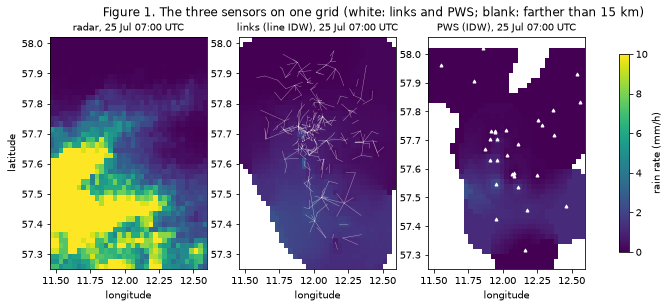

In [5]:
storm = pd.Timestamp("2015-07-25 07:00")
k = times.get_loc(storm)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (title, f) in zip(axes, [("radar", R[k]), ("links (line IDW)", C[k]), ("PWS (IDW)", P[k])]):
    im = ax.imshow(np.ma.masked_invalid(f), origin="lower", cmap="viridis", vmin=0, vmax=10,
                   extent=[grid.lon[0], grid.lon[-1], grid.lat[0], grid.lat[-1]], aspect="auto")
    ax.set_title(f"{title}, {storm:%d %b %H:%M} UTC")
    ax.set_xlabel("longitude")
axes[0].set_ylabel("latitude")
for r in links.itertuples():
    axes[1].plot([r.site_0_lon, r.site_1_lon], [r.site_0_lat, r.site_1_lat], color="w", lw=0.4, alpha=0.6)
axes[2].plot(pws_lon, pws_lat, "w^", ms=3)
fig.colorbar(im, ax=axes, label="rain rate (mm/h)", shrink=0.85)
fig.suptitle("Figure 1. The three sensors on one grid (white: links and PWS; blank: farther than 15 km)")
plt.show()

The radar sees the whole domain; the links and the PWS only the city and its
surroundings. Inside the sensor network the three agree on where the rain is, and the
sensors are the closer to the ground.

## 3. Radar adjusted with links and PWS, by hand

Following tutorial 6, the additive adjustment keeps the radar's pattern and corrects its
amount near the sensors. At each observation $j$ the radar is sampled the way the sensor
sees the rain - averaged along the path for a link, in the cell for a PWS - giving the
residual $e_j = o_j - \bar R_j$; the residuals are interpolated by IDW and added:

$$R_{RCP}(\mathbf{x}) = \max\!\left(0,\ R(\mathbf{x}) + \frac{\sum_j w_j e_j}{\sum_j w_j}\right),$$

with the radar unchanged beyond 15 km from every observation. With only links it is `RC`,
with only PWS `RP`, with both `RCP`. It is computed independently every five minutes.

In [6]:
A_link = path_weights(grid, links)                                # (link, cell): mean along the path
r_flat = np.nan_to_num(R.reshape(times.size, -1)).T              # (cell, time)
res_c = link_v - A_link @ r_flat
pc = cell_index(grid, pws_lat, pws_lon)
res_p = pws_v - r_flat[pc] if pc.size else np.zeros((0, times.size))
mx, my = to_local_xy(links.mid_lat.values, links.mid_lon.values, lat0, lon0)
W_m = idw_weights(np.r_[mx, px], np.r_[my, py], cx, cy, 2.0, 15_000.0, 12).astype("float32")
corr = _interp(W_m, np.concatenate([res_c, res_p]).astype("float32"))
RCP = np.where(np.isfinite(corr), np.clip(r_flat + corr, 0, None), r_flat).T.reshape(R.shape)
CP = _interp(np.concatenate([W_c, W_p], 1).astype("float32") if pws_v.shape[0] else W_c.astype("float32"),
             np.concatenate([V, pws_v]).astype("float32")).T.reshape(R.shape)

def at_gauges_hourly(F):
    f = pd.DataFrame(F.reshape(times.size, -1)[:, gauge_cells], index=times)
    o = pd.DataFrame(G, index=times)
    fh = f.resample("1h", closed="right", label="right").mean().values.ravel()
    oh = o.resample("1h", closed="right", label="right").mean().values.ravel()
    return scoring.point_scores(fh, oh)

table = pd.DataFrame({name: at_gauges_hourly(F) for name, F in
                      [("radar R", R), ("links C", C), ("PWS P", P), ("links + PWS CP", CP), ("radar adjusted RCP", RCP)]}).T
print("Hourly rain at the 10 city gauges, 22-29 July (mm/h):")
print(table.round(2))

Hourly rain at the 10 city gauges, 22-29 July (mm/h):
                         n  RMSE  corr  bias
radar R             1920.0  0.91  0.57 -0.10
links C             1920.0  0.57  0.85  0.14
PWS P               1920.0  0.72  0.76 -0.19
links + PWS CP      1920.0  0.57  0.85  0.13
radar adjusted RCP  1920.0  0.56  0.86  0.15


At the gauges, every sensor map and the adjusted radar are closer to the ground than the
radar alone: this radar reads low and smooth over the city. That is the *mapping* gain of
tutorials 5 and 6. The question here is whether it survives being **moved forward** in time.

## 4. Whose motion? Nowcasting a sensor map

Every pysteps nowcast starts with a motion field estimated from the last few fields of the
product itself (tutorial 7). For the radar that is the storm's motion. A link or PWS map is
different: it shows rain only where sensors are, so its "motion" is mostly the network
switching on and off. The alternative is to estimate the motion on the **radar** and move
the sensor map along it.

motion over wet cells: radar 39 km/h; link map 20 km/h; adjusted radar 28 km/h
link map's motion differs from the radar's by 26 km/h, the adjusted radar's by 18 km/h


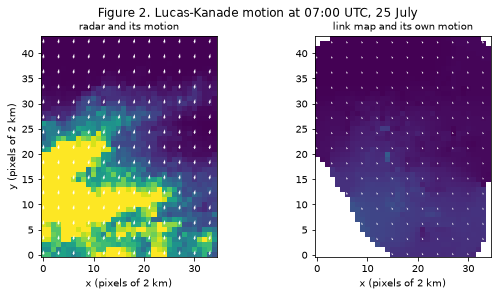

In [7]:
meta = metadata(grid, 5, product="tutorial")
hist = lambda F, i: np.nan_to_num(F[i - 5:i + 1])
v_r = M.motion(hist(R, k), meta, "LK")
v_c = M.motion(hist(C, k), meta, "LK")
v_rcp = M.motion(hist(RCP, k), meta, "LK")
wet = R[k] > 0.1
speed = lambda v: np.hypot(*v)[wet].mean() * 2.0 * 12           # pixels per 5 min -> km/h
print(f"motion over wet cells: radar {speed(v_r):.0f} km/h; link map {speed(v_c):.0f} km/h; "
      f"adjusted radar {speed(v_rcp):.0f} km/h")
print(f"link map's motion differs from the radar's by {np.hypot(*(v_c - v_r))[wet].mean() * 24:.0f} km/h, "
      f"the adjusted radar's by {np.hypot(*(v_rcp - v_r))[wet].mean() * 24:.0f} km/h")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
step = 3
yy, xx = np.mgrid[0:ny:step, 0:nx:step]
for ax, (title, f, v) in zip(axes, [("radar and its motion", R[k], v_r), ("link map and its own motion", C[k], v_c)]):
    ax.imshow(np.ma.masked_invalid(f), origin="lower", cmap="viridis", vmin=0, vmax=10)
    ax.quiver(xx, yy, v[0][::step, ::step], v[1][::step, ::step], color="w", scale=60)
    ax.set_title(title)
    ax.set_xlabel("x (pixels of 2 km)")
axes[0].set_ylabel("y (pixels of 2 km)")
fig.suptitle("Figure 2. Lucas-Kanade motion at 07:00 UTC, 25 July")
plt.show()

## 5. Scoring every nowcast the same way

To compare nowcasts of different products fairly, every one is scored on the **same issue
times, cells and gauges**:

- against the future **radar**, on the cells the radar's own motion can reach from inside the
  domain (rain flowing in from outside is unknown to every method), and separately within
  10 km of a link or PWS (the *sensor area*);
- at the **city gauges**, the next-hour total: the mean of the 12 lead times against the
  gauge's total over the same hour.

The project reduces each forecast to additive sums (`scoring.stats`: contingency counts,
error sums, FSS terms), so scores pool over issue times and can be bootstrapped by storm
day. Here: every 30 minutes of the storm of 25 July while at least 5% of the radar domain
is wet.

In [8]:
area = (np.min(np.hypot(cx[:, None] - np.r_[vx, px][None], cy[:, None] - np.r_[vy, py][None]), 1)
        <= 10_000).reshape(grid.shape)
issues = [i for i in range(times.size) if times[i].date() == storm.date() and times[i].minute % 30 == 0
          and i >= 5 and i + 12 < times.size and np.nanmean(R[i] > 0.1) > 0.05]
print(len(issues), "issue times on 25 July")

def nowcasts(i):
    """Physics nowcasts at issue index i: {name: (12, y, x) mm/h}."""
    vr = M.motion(hist(R, i), meta, "LK")
    out = {"R persistence": np.repeat(np.nan_to_num(R[i:i + 1]), 12, 0),
           "R extrapolation": M.deterministic("extrapolation", hist(R, i), meta, vr, 12)}
    out["C extrapolation, own motion"] = M.deterministic("extrapolation", hist(C, i), meta,
                                                         M.motion(hist(C, i), meta, "LK"), 12)
    out["C extrapolation, radar motion"] = M.deterministic("extrapolation", hist(C, i), meta, vr, 12)
    out["CP extrapolation, radar motion"] = M.deterministic("extrapolation", hist(CP, i), meta, vr, 12)
    out["RCP extrapolation, radar motion"] = M.deterministic("extrapolation", hist(RCP, i), meta, vr, 12)
    return vr, {k_: np.clip(np.nan_to_num(f), 0, None) for k_, f in out.items()}

S, GV, GO = {}, {}, []
for i in issues:
    vr, fc = nowcasts(i)
    reach = M.reachable(vr, grid.shape, 12)
    masks = {"domain": reach, "area": reach & area[None]}
    obs = R[i + 1:i + 13]
    for name, f in fc.items():
        S.setdefault(name, []).append(scoring.stats(f, obs, masks))
        GV.setdefault(name, []).append(f.reshape(12, -1)[:, gauge_cells].mean(0))
    GO.append(G[i + 1:i + 13].mean(0))
GO = np.array(GO)

def summary(S, GV):
    rows = {}
    for name in S:
        sc = scoring.pooled(np.array(S[name]))
        rows[name] = {"CSI 1 mm/h, 30 min": sc["CSI_1"][5, 0], "CSI 60 min": sc["CSI_1"][11, 0],
                      "CSI 60 min, sensor area": sc["CSI_1"][11, 1], "MAE 60 min": sc["MAE"][11, 0],
                      **{f"gauges next hour: {k_}": v for k_, v in
                         scoring.point_scores(np.array(GV[name]).ravel(), GO.ravel()).items() if k_ != "n"}}
    return pd.DataFrame(rows).T

print(summary(S, GV).round(2))

29 issue times on 25 July


                                 CSI 1 mm/h, 30 min  CSI 60 min  CSI 60 min, sensor area  MAE 60 min  gauges next hour: RMSE  gauges next hour: corr  gauges next hour: bias
R persistence                                  0.37        0.19                     0.19        0.91                    1.15                    0.34                   -0.04
R extrapolation                                0.59        0.48                     0.48        1.12                    2.00                    0.24                    0.72
C extrapolation, own motion                    0.25        0.13                     0.13        1.01                    1.18                    0.62                    0.36
C extrapolation, radar motion                  0.32        0.28                     0.28        0.80                    0.53                    0.84                    0.13
CP extrapolation, radar motion                 0.32        0.28                     0.28        0.80                    0.53           

Two things show up even on one storm, and the project confirms them over a summer
(section 7). A link map moved along **its own** motion scores well below the same map moved
along the **radar's** motion. And against the radar, the radar's own extrapolation is hard
to beat - it is, after all, being compared with itself - while at the gauges the products
that carry the sensors' amounts do better. Which reference you
score against changes the answer, so both are always reported.

## 6. Learning from all three sensors

A neural network can take every sensor at once and learn both the motion and how much to
trust each source. The project trains a small **U-Net** (the architecture of RainNet, Ayzel
et al. 2020) that maps the last 30 minutes of fields to the next 60 minutes, all 12 lead
times at once. Its inputs, per 5-minute step, are `log1p` rain rates plus masks:

| sensor | channels |
|---|---|
| radar `R` | rate; has-data mask |
| links `C` | map (0 beyond 15 km); cells holding a reporting link |
| PWS `P` | map (0 beyond 15 km); cells holding a reporting station |

The split is by **day** so that no storm is in two sets: training 22-24 and 27-29 July,
validation (early stopping) 26 July, test 25 July. The loss is the squared error of
`log1p` rates weighted by `1 + rate`. Two models are trained, one on the radar alone and one
on radar, links and PWS, with the project's network (`learn.build_model`) and loss.

In [9]:
import torch
from multisensor_nowcasting import learn

torch.manual_seed(0)
np.random.seed(0)
# once pysteps (OpenCV) has run in this process, multi-threaded torch crashes on macOS: one thread
torch.set_num_threads(1)

Ci = np.zeros_like(C); Pi = np.zeros_like(C)
cells_vg = cell_index(grid, vlat, vlon)
for t_ in range(times.size):
    ok_ = np.isfinite(V[:, t_])
    Ci[t_].flat[np.unique(cells_vg[ok_ & (cells_vg >= 0)])] = 1
    if pws_v.shape[0]:
        okp = np.isfinite(pws_v[:, t_])
        Pi[t_].flat[np.unique(pc[okp])] = 1
FIELDS = {"R": (R, np.isfinite(R).astype(float)), "C": (C, Ci), "P": (P, Pi)}

def make_x(i, inputs):
    ch = []
    for s in inputs:
        v, m = FIELDS[s]
        ch += [np.log1p(np.clip(np.nan_to_num(v[i - 5:i + 1]), 0, None)), m[i - 5:i + 1]]
    return np.concatenate(ch).astype("float32")

def make_y(i):
    y = R[i + 1:i + 13]
    return np.log1p(np.clip(np.nan_to_num(y), 0, None)).astype("float32"), np.isfinite(y).astype("float32")

day = times.floor("D")
def samples(days):
    out = []
    for i in range(5, times.size - 12):
        if day[i - 5] == day[i + 12] and day[i] in days and np.nanmean(R[i] > 0.1) > 0.05:
            out.append(i)
    return np.array(out)

train_days = pd.to_datetime(["2015-07-22", "2015-07-23", "2015-07-24", "2015-07-27", "2015-07-28", "2015-07-29"])
tr, va = samples(train_days), samples(pd.to_datetime(["2015-07-26"]))
print("training samples", tr.size, "| validation", va.size)

def train(inputs, epochs=12, patience=4):
    Xtr = np.stack([make_x(i, inputs) for i in tr]); Ytr, Mtr = map(np.stack, zip(*[make_y(i) for i in tr]))
    Xva = np.stack([make_x(i, inputs) for i in va]); Yva, Mva = map(np.stack, zip(*[make_y(i) for i in va]))
    mu, sd = Xtr.mean((0, 2, 3)), Xtr.std((0, 2, 3)) + 1e-6      # training-set normalisation
    norm = lambda X: (X - mu[None, :, None, None]) / sd[None, :, None, None]
    model = learn.build_model(Xtr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    pad = learn._pad(grid.shape)
    best, bad, state, curve = np.inf, 0, None, []
    for ep in range(epochs):
        model.train()
        for b in np.array_split(np.random.permutation(tr.size), max(1, tr.size // 32)):
            loss = learn._loss(learn._forward(model, norm(Xtr[b]), None, pad), torch.as_tensor(Ytr[b]), torch.as_tensor(Mtr[b]))
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = float(learn._loss(learn._forward(model, norm(Xva), None, pad), torch.as_tensor(Yva), torch.as_tensor(Mva)))
        curve.append(v)
        if v < best - 1e-5:
            best, bad, state = v, 0, {k_: t.clone() for k_, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(state)
    def forecast(i):
        with torch.no_grad():
            out = learn._forward(model, norm(make_x(i, inputs)[None]), None, pad).numpy()[0]
        return np.expm1(out.clip(0, 6))
    return forecast, curve

t_ = time.time()
models = {}
for name, inputs in [("U-Net, radar only", ("R",)), ("U-Net, radar + links + PWS", ("R", "C", "P"))]:
    models[name], curve = train(inputs)
    print(f"{name}: {len(curve)} epochs, validation loss {min(curve):.4f}")
print(f"training took {time.time() - t_:.0f} s")

training samples 602 | validation 231


U-Net, radar only: 7 epochs, validation loss 0.3734


U-Net, radar + links + PWS: 11 epochs, validation loss 0.3862
training took 98 s


In [10]:
for name, fc in models.items():
    for i in issues:
        vr = M.motion(hist(R, i), meta, "LK")
        reach = M.reachable(vr, grid.shape, 12)
        f = fc(i)
        S.setdefault(name, []).append(scoring.stats(f, R[i + 1:i + 13], {"domain": reach, "area": reach & area[None]}))
        GV.setdefault(name, []).append(f.reshape(12, -1)[:, gauge_cells].mean(0))
print(summary(S, GV).round(2))

                                 CSI 1 mm/h, 30 min  CSI 60 min  CSI 60 min, sensor area  MAE 60 min  gauges next hour: RMSE  gauges next hour: corr  gauges next hour: bias
R persistence                                  0.37        0.19                     0.19        0.91                    1.15                    0.34                   -0.04
R extrapolation                                0.59        0.48                     0.48        1.12                    2.00                    0.24                    0.72
C extrapolation, own motion                    0.25        0.13                     0.13        1.01                    1.18                    0.62                    0.36
C extrapolation, radar motion                  0.32        0.28                     0.28        0.80                    0.53                    0.84                    0.13
CP extrapolation, radar motion                 0.32        0.28                     0.28        0.80                    0.53           

Trained on six days, these networks are toys: the numbers above say how to set the
comparison up, not which method wins. Over a whole summer, with the RNN's link retrieval
and 15 models (every combination of sensors, two targets and a hybrid that corrects the
pysteps extrapolation), the project gives the answer in the next section.

## 7. At scale: the project's results

[`projects/nowcasting/multisensor`](../projects/nowcasting/multisensor/README.md) runs this
chain over June-August 2015 in Gothenburg and over the rain events of November 2023 to
June 2024 in New York (MRMS radar, NYC Mesh links, Weather Underground PWS, ASOS gauges).
Its tables, read here from `results/`:

In [11]:
res = ROOT / "projects" / "nowcasting" / "multisensor" / "results"
show = ["R|extrapolation", "R|steps_mean", "CP|extrapolation_Rmotion", "RCP|extrapolation_Rmotion",
        "learned|in-R>tgt-R", "learned|in-CP>tgt-R", "learned|in-RCP>tgt-R", "learned|hybrid"]
for net in ("openmrg", "openmesh"):
    f_s, f_g = res / f"scores_{net}.csv", res / f"gauges_{net}.csv"
    if not f_s.exists():
        print(f"{net}: run the project first (see its README)")
        continue
    sc, ga = pd.read_csv(f_s), pd.read_csv(f_g)
    a = sc[(sc.region == "domain") & (sc.lead_min.isin([30, 60]))].pivot_table(index="forecast", columns="lead_min", values="CSI_1")
    b = ga[ga.what == "next-hour total"].set_index("forecast")[["RMSE", "corr"]]
    t = a.join(b).reindex([s for s in show if s in a.index])
    t.columns = ["CSI 30 min", "CSI 60 min", "gauges next hour RMSE", "gauges next hour corr"]
    print(net)
    print(t.round(2), "\n")

openmrg
                           CSI 30 min  CSI 60 min  gauges next hour RMSE  gauges next hour corr
forecast                                                                                       
R|extrapolation                  0.47        0.35                   1.20                   0.56
R|steps_mean                     0.47        0.36                   1.11                   0.57
CP|extrapolation_Rmotion         0.32        0.26                   1.02                   0.66
RCP|extrapolation_Rmotion        0.38        0.30                   1.02                   0.66
learned|in-R>tgt-R               0.41        0.29                   1.13                   0.54
learned|in-CP>tgt-R              0.26        0.22                   1.23                   0.46
learned|in-RCP>tgt-R             0.39        0.29                   1.17                   0.51
learned|hybrid                   0.46        0.35                   1.32                   0.55 

openmesh
                     

## 8. Summary

- Nowcasting with several sensors starts with **one grid and one clock**: every sensor as a
  5-minute field on the radar's grid, with a mask where it knows nothing.
- Missing sensors must drop out of the interpolation step by step, not count as dry.
- A link or PWS map has no motion of its own worth extrapolating; move it along the
  **radar's** motion, or merge it into the radar first.
- Score every nowcast on the same issue times and cells, against the radar *and* at
  independent gauges, with intervals over storm days: the two references can disagree.
- A network can take every sensor at once, but in the project's two networks none beats
  pysteps: against the radar the radar's extrapolation stays best, and at the gauges the
  radar adjusted with links and PWS, moved along the radar's motion, does (section 7).

**Previous:** [8 · Learned nowcasting](08_learned_nowcasting.ipynb) · [Index](README.md)

In [12]:
print(f"notebook ran in {time.time() - T0:.0f} s")

notebook ran in 118 s


## 9. References and links

- Andersson, J. C. M. et al. (2022): OpenMRG: Open data from Microwave links, Radar, and Gauges for rainfall quantification in Gothenburg, Sweden. *Earth Syst. Sci. Data*, 14, 5411-5426. <https://doi.org/10.5194/essd-14-5411-2022>; data <https://doi.org/10.5281/zenodo.7107689>
- OpenMRG2 Netatmo PWS: <https://github.com/OpenSenseAction/OpenMRG2>
- Jacoby et al. (2026): OpenMesh: wireless signal dataset for opportunistic urban weather sensing in New York City. *Earth Syst. Sci. Data*, 18, 5817. <https://doi.org/10.5194/essd-18-5817-2026>
- de Vos, L. W. et al. (2019): Quality control for crowdsourced personal weather stations to enable operational rainfall monitoring. *Geophys. Res. Lett.* <https://doi.org/10.1029/2019GL083731>; pypwsqc <https://github.com/OpenSenseAction/pypwsqc>
- Pulkkinen, S. et al. (2019): Pysteps: an open-source Python library for probabilistic precipitation nowcasting (v1.0). *Geosci. Model Dev.*, 12, 4185-4219. <https://doi.org/10.5194/gmd-12-4185-2019>
- Ayzel, G., Scheffer, T. and Heistermann, M. (2020): RainNet v1.0: a convolutional neural network for radar-based precipitation nowcasting. *Geosci. Model Dev.*, 13, 2631-2644. <https://doi.org/10.5194/gmd-13-2631-2020>
- OpenSense training school 2025, merging and nowcasting sessions: <https://github.com/OpenSenseAction/TrainingSchoolMergingApplication>
- Every reference of FieldSense: [docs/references.md](../docs/references.md)